# 01 — Feature Screening

## Purpose
Pre-modeling feature screening for all 5 behavioral target series, using the
core library (`src/irrbb_behavioral_model.py`) against the synthetic panel
generated in `00_data_generation.ipynb`. This notebook implements the screening
stage described in `docs/methodology.md` §3:

1. **§3.1 — Lag-optimal correlation screening** (`find_correl`)
2. **§3.2 — Multicollinearity check (VIF)** (`cek_vif`)
3. **§2.4 — EMA smoothing** (`add_ema`)
4. **§3.3 — PCA dimensionality reduction** (`run_pca`, optional alternative)

Output: a shortlisted candidate predictor pool **per target**, to be carried
into `02_arimax_model_search.ipynb`.


In [1]:
import sys, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import irrbb_behavioral_model as m

plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("../data/raw/synthetic_irrbb_data.csv", parse_dates=["Date"])
TARGETS = ["TDER_IDR", "TDER_USD", "PL_PREPAY", "MTG_PREPAY", "JF_PREPAY"]
MACRO_COLS = [c for c in df.columns if c.startswith("X_")]

print(f"Data shape: {df.shape}")
print(f"Targets: {TARGETS}")
print(f"Macro predictors ({len(MACRO_COLS)}): {MACRO_COLS}")
df.head(3)


Data shape: (72, 19)
Targets: ['TDER_IDR', 'TDER_USD', 'PL_PREPAY', 'MTG_PREPAY', 'JF_PREPAY']
Macro predictors (12): ['X_BI7DRR', 'X_FEDFUNDS', 'X_CPI_YOY', 'X_USDIDR', 'X_IHSG', 'X_BRENT', 'X_COAL', 'X_GDP_YOY', 'X_CAPEX', 'X_CCI', 'X_RESERVES', 'X_SUN10Y']


,Date,X_BI7DRR,X_FEDFUNDS,X_CPI_YOY,X_USDIDR,X_IHSG,X_BRENT,X_COAL,X_GDP_YOY,X_CAPEX,X_CCI,X_RESERVES,X_SUN10Y,XAO,TDER_IDR,TDER_USD,PL_PREPAY,MTG_PREPAY,JF_PREPAY
0,2019-01-01,5.750000,2.250000,2.90000,14200.000000,6200.000000,60.000000,70.000000,5.000000,13.656250,125.000000,120.000000,7.900000,0.0,0.032771,0.021926,0.036452,0.020426,0.055815
1,2019-02-01,5.774649,2.239545,2.51665,14179.033925,6088.499998,67.490581,72.602840,4.732671,14.688067,122.879746,123.488726,7.927691,0.0,0.022639,0.032636,0.026780,0.021714,0.068427
2,2019-03-01,5.767308,2.238602,2.84771,14389.163841,6133.435915,54.109046,67.983118,4.620847,11.902561,121.523821,125.347651,7.862158,0.0,0.031951,0.037041,0.033414,0.018380,0.084719


## 1. Lag-Optimal Correlation Screening (Methodology §3.1)

For each target, `find_correl` scans every macro predictor across candidate lags
$L \in \{0,1,2,3\}$ and reports the lag maximizing $|\rho_j(L)|$. This is a fast,
model-free first-pass filter — **not** the final model specification (that comes
from the full ARIMAX combinatorial search in `02_arimax_model_search.ipynb`).


In [2]:
correl_results = {}
for target in TARGETS:
    res = m.find_correl(df, target_col=target, lag_grid=[0, 1, 2, 3], correl_threshold=0.0)
    res = res.sort_values("Correl Optimum", key=np.abs, ascending=False).reset_index(drop=True)
    correl_results[target] = res

for target in TARGETS:
    print(f"=== {target} — Top 5 correlated predictors ===")
    print(correl_results[target].head(5).to_string(index=False))
    print()


=== TDER_IDR — Top 5 correlated predictors ===
 Variabel  Lag Optimum  Correl Optimum
      XAO            0        0.588202
X_GDP_YOY            0       -0.560040
 X_SUN10Y            0        0.553905
 X_BI7DRR            0        0.297732
   X_IHSG            0       -0.296278

=== TDER_USD — Top 5 correlated predictors ===
  Variabel  Lag Optimum  Correl Optimum
X_FEDFUNDS            3        0.620299
  X_BI7DRR            1        0.518743
       XAO            0        0.388302
    X_IHSG            3        0.355253
  X_USDIDR            0        0.351438

=== PL_PREPAY — Top 5 correlated predictors ===
 Variabel  Lag Optimum  Correl Optimum
 X_SUN10Y            0       -0.645764
  X_BRENT            0        0.597808
   X_COAL            0        0.543907
X_CPI_YOY            0        0.541949
X_GDP_YOY            0        0.539593

=== MTG_PREPAY — Top 5 correlated predictors ===
 Variabel  Lag Optimum  Correl Optimum
 X_SUN10Y            0       -0.671391
      XAO           

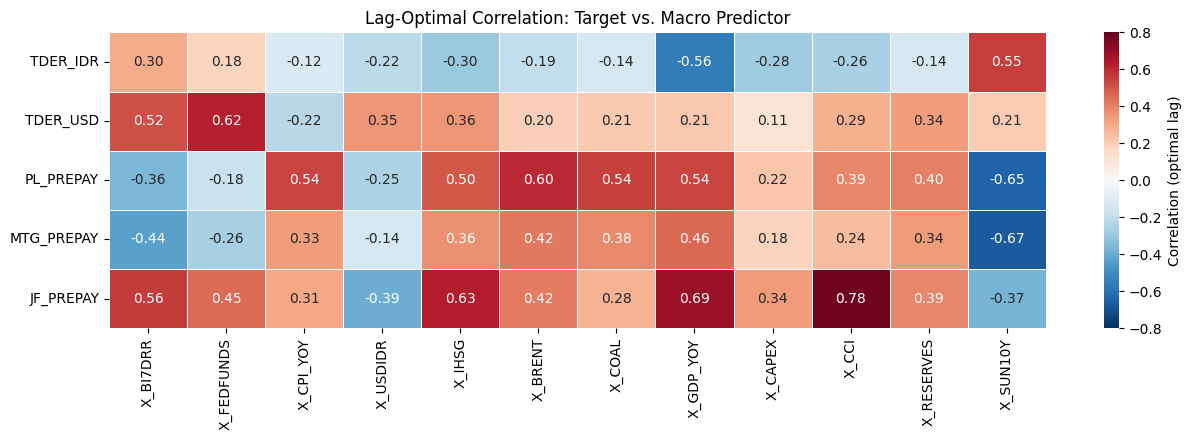

In [3]:
# Consolidated heatmap: optimal-lag correlation, target x predictor
heat = pd.DataFrame(index=TARGETS, columns=MACRO_COLS, dtype=float)
for target in TARGETS:
    r = correl_results[target].set_index("Variabel")["Correl Optimum"]
    for c in MACRO_COLS:
        heat.loc[target, c] = r.get(c, np.nan)

fig, ax = plt.subplots(figsize=(13, 4.5))
sns.heatmap(heat.astype(float), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-0.8, vmax=0.8, linewidths=0.5, ax=ax, cbar_kws={"label": "Correlation (optimal lag)"})
ax.set_title("Lag-Optimal Correlation: Target vs. Macro Predictor")
plt.tight_layout()
plt.show()


**Observation:** several macro predictors show meaningful correlation with
multiple targets simultaneously (e.g. `X_SUN10Y`, `X_GDP_YOY`, `X_BRENT`,
`X_COAL` all co-move strongly during the 2022 hiking-cycle regime). This is a
classic sign of **macro co-trending** — real-world macro series rarely move
independently, and correlation alone cannot distinguish a predictor's genuine
causal driver role from incidental co-movement during a shared historical
episode. This motivates the VIF check next (§3.2), and is precisely why final
model selection in `02_arimax_model_search.ipynb` relies on **out-of-sample
MAPE + residual diagnostics + coefficient significance** rather than
correlation ranking alone.


## 2. Multicollinearity Check — VIF (Methodology §3.2)

$$
\text{VIF}_j = \frac{1}{1-R_j^2}
$$

Checked first across **all 12 macro predictors together** (worst case), to
illustrate the scale of the co-trending problem observed above.


In [4]:
vif_all = m.cek_vif(df, MACRO_COLS)
vif_all = vif_all.sort_values("VIF", ascending=False).reset_index(drop=True)
vif_all


,Variabel,VIF
0,X_IHSG,2713.467877
1,X_USDIDR,2158.773089
2,X_CCI,1602.137344
3,X_SUN10Y,1331.478861
4,X_RESERVES,883.755420
5,X_BRENT,365.414122
6,X_BI7DRR,274.631662
7,X_COAL,100.878976
8,X_CPI_YOY,56.261510
9,X_GDP_YOY,50.949339


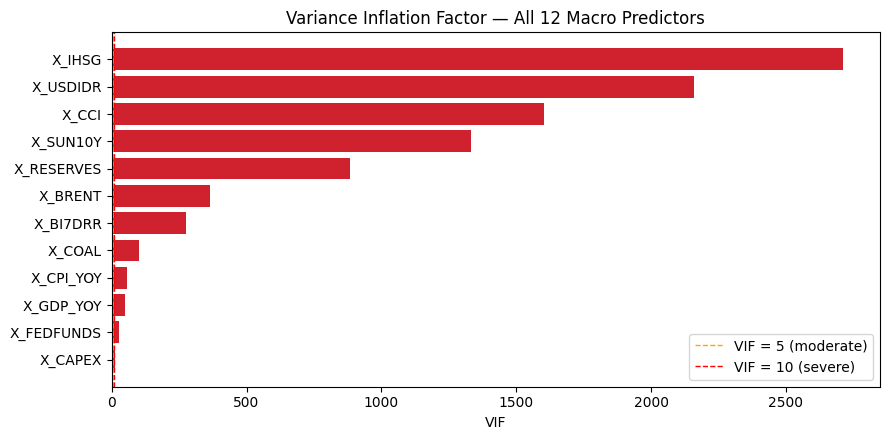

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#cf222e" if v > 10 else ("#bf8700" if v > 5 else "#1a7f37") for v in vif_all["VIF"]]
ax.barh(vif_all["Variabel"], vif_all["VIF"], color=colors)
ax.axvline(5, color="orange", linestyle="--", lw=1, label="VIF = 5 (moderate)")
ax.axvline(10, color="red", linestyle="--", lw=1, label="VIF = 10 (severe)")
ax.set_xlabel("VIF")
ax.set_title("Variance Inflation Factor — All 12 Macro Predictors")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()


**Observation:** as expected from the heatmap above, several predictors show
**severe multicollinearity (VIF > 10)** when included together — a direct
consequence of shared trend/regime co-movement over 2019-2024. Using all 12
predictors jointly in a single ARIMAX specification would produce unstable,
potentially sign-flipping coefficient estimates. This confirms the value of
the combinatorial **small-subset search** (`x_num` = 1 or 2 predictors per
specification) used in `run_arima`, rather than a single kitchen-sink
regression — each candidate specification is checked in isolation, keeping
VIF low by construction within any given subset.

A smaller candidate pool (e.g. one predictor per macro category) is checked
below for comparison.


In [6]:
candidate_pool = ["X_BI7DRR", "X_CPI_YOY", "X_GDP_YOY", "X_CCI"]
vif_pool = m.cek_vif(df, candidate_pool).sort_values("VIF", ascending=False).reset_index(drop=True)
vif_pool


,Variabel,VIF
0,X_CCI,88.200311
1,X_BI7DRR,41.917098
2,X_CPI_YOY,13.760777
3,X_GDP_YOY,6.698131


## 3. EMA Smoothing (Methodology §2.4)

$$
\text{EMA}_t^{(\text{span})} = \alpha\, x_t + (1-\alpha)\,\text{EMA}_{t-1}^{(\text{span})}, \qquad \alpha = \frac{2}{\text{span}+1}
$$

Applied to two illustrative predictors (`X_BI7DRR`, `X_CCI`) at spans
{3, 6, 12} months, to visualize how smoothing trades off noise reduction
against responsiveness to genuine turning points.


Generated columns: ['X_BI7DRR_EMA3', 'X_BI7DRR_EMA6', 'X_BI7DRR_EMA12', 'X_CCI_EMA3', 'X_CCI_EMA6', 'X_CCI_EMA12']


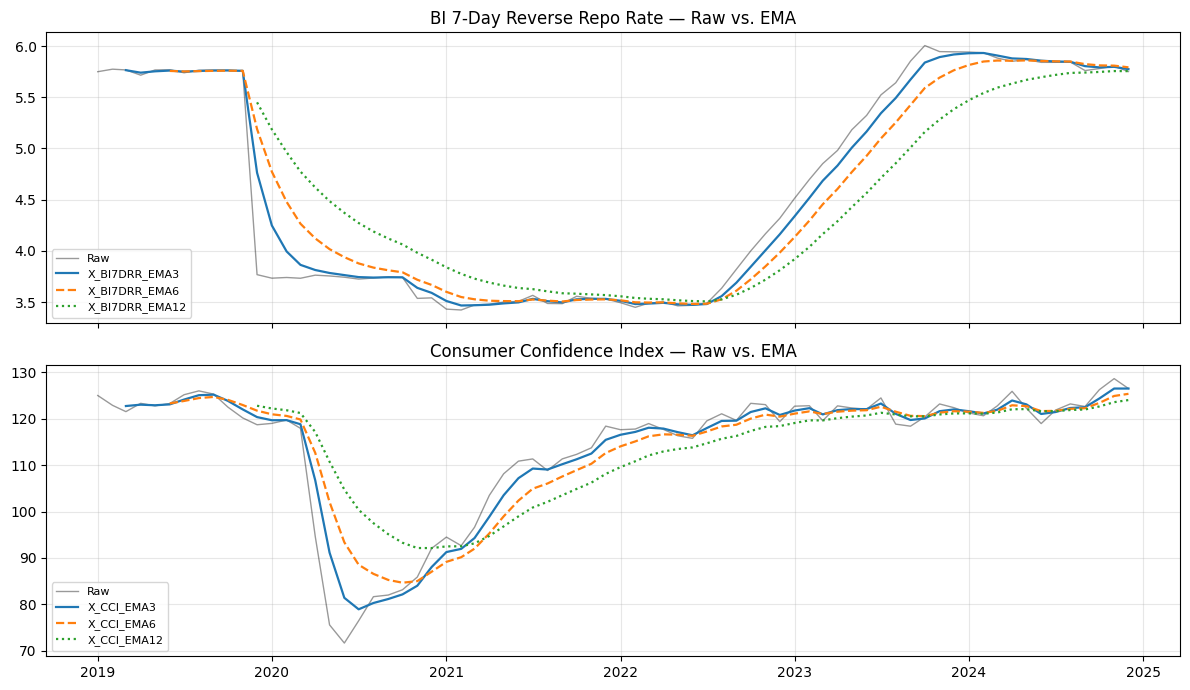

In [7]:
df_ema = m.add_ema(df, cols=["X_BI7DRR", "X_CCI"], spans=(3, 6, 12), lags=(0,))
ema_cols_bi = [c for c in df_ema.columns if c.startswith("X_BI7DRR_EMA")]
ema_cols_cci = [c for c in df_ema.columns if c.startswith("X_CCI_EMA")]
print("Generated columns:", ema_cols_bi + ema_cols_cci)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(df_ema["Date"], df_ema["X_BI7DRR"], color="black", lw=1, alpha=0.4, label="Raw")
for c, style in zip(ema_cols_bi, ["-", "--", ":"]):
    axes[0].plot(df_ema["Date"], df_ema[c], style, lw=1.6, label=c)
axes[0].set_title("BI 7-Day Reverse Repo Rate — Raw vs. EMA")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(df_ema["Date"], df_ema["X_CCI"], color="black", lw=1, alpha=0.4, label="Raw")
for c, style in zip(ema_cols_cci, ["-", "--", ":"]):
    axes[1].plot(df_ema["Date"], df_ema[c], style, lw=1.6, label=c)
axes[1].set_title("Consumer Confidence Index — Raw vs. EMA")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


**Observation:** the short span (EMA3) tracks the raw series closely, while
EMA12 lags visibly at regime turning points (e.g. the Covid confidence crash)
but produces a much smoother trend signal. This span choice becomes a
hyperparameter to consider when building lagged features for the ARIMAX/HGBR
stage — smoother inputs may improve out-of-sample stability at the cost of
slower responsiveness to genuine shocks.


## 4. PCA — Dimensionality Reduction (Methodology §3.3, optional)

Given the multicollinearity observed in §2, PCA is checked as an alternative
to manual variable-subset selection — condensing the 12 macro predictors into
a small set of orthogonal components explaining most of the variance.


In [8]:
scores_df, loadings_df, evr_df = m.run_pca(df, standardize=True, var_threshold=0.80)
print(f"Components retained to reach 80% cumulative variance: {scores_df.shape[1] - 1}")
evr_df


Components retained to reach 80% cumulative variance: 4


,Komponen,EVR,EVR Cum.
0,PC1,0.488262,0.488262
1,PC2,0.157429,0.645691
2,PC3,0.123069,0.768760
3,PC4,0.085434,0.854194


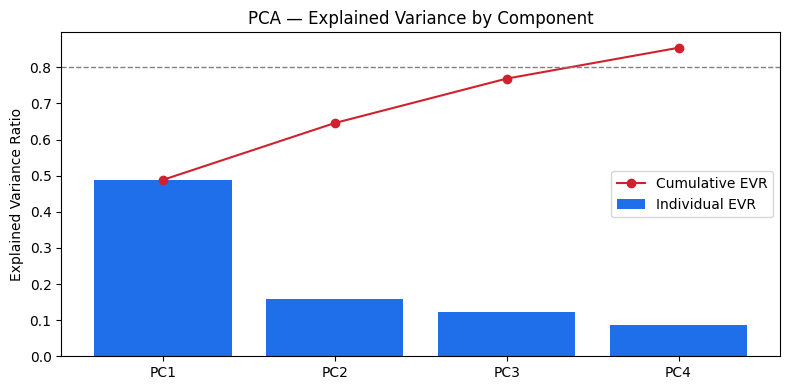

,X_BI7DRR,X_FEDFUNDS,X_CPI_YOY,X_USDIDR,X_IHSG,X_BRENT,X_COAL,X_GDP_YOY,X_CAPEX,X_CCI,X_RESERVES,X_SUN10Y,XAO
PC1,0.16,0.26,0.25,-0.07,0.39,0.36,0.31,0.34,0.09,0.35,0.30,-0.24,-0.26
PC2,0.51,0.50,-0.28,0.47,0.06,-0.09,-0.02,-0.11,0.22,0.00,0.04,0.34,0.03
PC3,-0.38,-0.01,0.26,0.43,-0.05,0.22,0.38,-0.30,0.30,-0.32,0.27,-0.04,0.21
PC4,0.11,0.13,0.41,-0.12,0.00,0.23,0.29,-0.16,-0.50,0.04,-0.27,0.52,0.17


In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(evr_df["Komponen"], evr_df["EVR"], color="#1f6feb", label="Individual EVR")
ax.plot(evr_df["Komponen"], evr_df["EVR Cum."], color="#cf222e", marker="o", label="Cumulative EVR")
ax.axhline(0.8, color="gray", linestyle="--", lw=1)
ax.set_ylabel("Explained Variance Ratio")
ax.set_title("PCA — Explained Variance by Component")
ax.legend()
plt.tight_layout()
plt.show()

loadings_df.round(2)


**Observation:** PCA is retained here as a documented *alternative*, but the
project's primary path forward uses **manual variable-subset ARIMAX search**
rather than PCA components — because PCA components are linear combinations
of standardized macro variables and lose direct economic interpretability
(e.g. "a 100bps BI Rate increase raises the mortgage prepayment rate by X"
cannot be stated cleanly against `PC1`). Interpretability is a priority for a
*behavioral* model whose coefficients need to be explainable to ALCO/Treasury
stakeholders, per Methodology §1.4.


## 5. Consolidated Candidate Shortlist per Target

Combining the lag-correlation screening (§1) with a $|\rho| > 0.35$ shortlist
threshold and a manual VIF sanity check, producing the candidate pool to carry
into `02_arimax_model_search.ipynb`'s combinatorial `run_arima` search.


In [10]:
SHORTLIST_THRESHOLD = 0.35

shortlist = {}
for target in TARGETS:
    res = correl_results[target]
    keep = res[res["Correl Optimum"].abs() > SHORTLIST_THRESHOLD]["Variabel"].tolist()
    shortlist[target] = keep

shortlist_df = pd.DataFrame(
    [(t, ", ".join(v), len(v)) for t, v in shortlist.items()],
    columns=["Target", "Candidate Predictors (|corr| > 0.35)", "N Candidates"]
)
shortlist_df


,Target,Candidate Predictors (|corr| > 0.35),N Candidates
0,TDER_IDR,"XAO, X_GDP_YOY, X_SUN10Y",3
1,TDER_USD,"X_FEDFUNDS, X_BI7DRR, XAO, X_IHSG, X_USDIDR",5
2,PL_PREPAY,"X_SUN10Y, X_BRENT, X_COAL, X_CPI_YOY, X_GDP_YO...",10
3,MTG_PREPAY,"X_SUN10Y, XAO, X_GDP_YOY, X_BI7DRR, X_BRENT, X...",7
4,JF_PREPAY,"X_CCI, X_GDP_YOY, X_IHSG, XAO, X_BI7DRR, X_FED...",10


In [11]:
import json
with open("../data/processed/feature_shortlist.json", "w") as f:
    json.dump(shortlist, f, indent=2)
print("Saved shortlist to ../data/processed/feature_shortlist.json")
shortlist


Saved shortlist to ../data/processed/feature_shortlist.json


{'TDER_IDR': ['XAO', 'X_GDP_YOY', 'X_SUN10Y'],
 'TDER_USD': ['X_FEDFUNDS', 'X_BI7DRR', 'XAO', 'X_IHSG', 'X_USDIDR'],
 'PL_PREPAY': ['X_SUN10Y',
  'X_BRENT',
  'X_COAL',
  'X_CPI_YOY',
  'X_GDP_YOY',
  'XAO',
  'X_IHSG',
  'X_RESERVES',
  'X_CCI',
  'X_BI7DRR'],
 'MTG_PREPAY': ['X_SUN10Y',
  'XAO',
  'X_GDP_YOY',
  'X_BI7DRR',
  'X_BRENT',
  'X_COAL',
  'X_IHSG'],
 'JF_PREPAY': ['X_CCI',
  'X_GDP_YOY',
  'X_IHSG',
  'XAO',
  'X_BI7DRR',
  'X_FEDFUNDS',
  'X_BRENT',
  'X_RESERVES',
  'X_USDIDR',
  'X_SUN10Y']}

## Next Step
Proceed to **`02_arimax_model_search.ipynb`** — combinatorial ARIMAX grid
search (`run_arima`) restricted to each target's candidate predictor pool
above, followed by diagnostic-based model selection
(`evaluate_selected_models`) as specified in `docs/methodology.md` §1 and §4.
